# 01 — Exploratory Data Analysis: Brand24/mms

This notebook:
1. Loads the `Brand24/mms` dataset from HuggingFace
2. Prints the schema and per-language sample counts
3. Plots the label distribution per language as a stacked bar chart
4. Checks for a parallel-sample ID column
5. Saves `results/scores/label_distribution.csv`

In [1]:
import sys
from pathlib import Path

# Ensure repo root is on the path
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))
print('Repo root:', REPO_ROOT)

Repo root: /Users/laetitiasimon/clcs-eval


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from src.data.loader import LABEL_MAP, load_mms

SCORES_DIR = REPO_ROOT / 'results' / 'scores'
SCORES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load dataset and inspect schema

In [3]:
import os

# Load HF_TOKEN from .env if present (never hardcode credentials)
_env = REPO_ROOT / ".env"
if _env.exists():
    for _line in _env.read_text().splitlines():
        if "=" in _line and not _line.startswith("#"):
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip())

dataset = load_mms(cache_dir=str(REPO_ROOT / "data" / "raw"))


Generating train split: 0 examples [00:00, ? examples/s]

=== Brand24/mms schema ===
{'label': Value(dtype='int64', id=None), 'text': Value(dtype='large_string', id=None), 'cleanlab_self_confidence': Value(dtype='float64', id=None), 'language': Value(dtype='large_string', id=None), 'original_dataset': Value(dtype='large_string', id=None)}

=== Row counts per split ===
  train: 6,165,241 rows



In [4]:
# Show all splits
print('Splits:', list(dataset.keys()))
first_split = next(iter(dataset.values()))
print('\nFeatures:')
for col, feat in first_split.features.items():
    print(f'  {col:30s}  {feat}')

Splits: ['train']

Features:
  label                           Value(dtype='int64', id=None)
  text                            Value(dtype='large_string', id=None)
  cleanlab_self_confidence        Value(dtype='float64', id=None)
  language                        Value(dtype='large_string', id=None)
  original_dataset                Value(dtype='large_string', id=None)


In [5]:
# Show the first 3 rows of the first split
first_split.to_pandas().head(3)

,label,text,cleanlab_self_confidence,language,original_dataset
0,2,""" آللهمَ إني أسألك من الخير كله ..عاجله وآجله ...",0.210715,ar,ar_arsentdl
1,2,""" أتمنى الجنة ، لست صالحاً يا الله ولست خالياً...",0.595362,ar,ar_arsentdl
2,1,""" اللهم إني ظلمت نفسي ظلماً كثيراً ؛ ولآ يغفر ...",0.632893,ar,ar_arsentdl


## 2. Per-language sample counts

In [6]:
# Combine all splits into one DataFrame for EDA
dfs = []
for split_name, split_ds in dataset.items():
    df = split_ds.to_pandas()
    df['split'] = split_name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print('Total rows:', len(df_all))
print('Columns:', list(df_all.columns))
df_all.head(3)

Total rows: 6165241
Columns: ['label', 'text', 'cleanlab_self_confidence', 'language', 'original_dataset', 'split']


,label,text,cleanlab_self_confidence,language,original_dataset,split
0,2,""" آللهمَ إني أسألك من الخير كله ..عاجله وآجله ...",0.210715,ar,ar_arsentdl,train
1,2,""" أتمنى الجنة ، لست صالحاً يا الله ولست خالياً...",0.595362,ar,ar_arsentdl,train
2,1,""" اللهم إني ظلمت نفسي ظلماً كثيراً ؛ ولآ يغفر ...",0.632893,ar,ar_arsentdl,train


In [7]:
# Detect language and text columns
LANG_CANDIDATES = ['language', 'lang', 'Language']
TEXT_CANDIDATES = ['text', 'sentence', 'content', 'review']

lang_col = next((c for c in LANG_CANDIDATES if c in df_all.columns), None)
text_col = next((c for c in TEXT_CANDIDATES if c in df_all.columns), None)
label_col = 'label' if 'label' in df_all.columns else None

print(f'Language column : {lang_col}')
print(f'Text column     : {text_col}')
print(f'Label column    : {label_col}')

Language column : language
Text column     : text
Label column    : label


In [8]:
if lang_col:
    lang_counts = df_all[lang_col].value_counts().sort_index()
    print(f'Number of languages: {len(lang_counts)}')
    print(lang_counts.to_string())

Number of languages: 28
language
ar     932075
bg      62150
bs      36183
cs     196287
de     315887
el        500
en    2330465
es     418712
fa      13525
fr     210631
he       8619
hi      16999
hr      77594
hu      56682
it      12065
ja     209780
lv       5790
pl     236688
pt     157834
ru     110930
sk      56623
sl     113543
sq      44284
sr      76368
sv      41346
th      72319
ur      19660
zh     331702


## 3. Label distribution per language

In [9]:
if lang_col and label_col:
    # Map integer labels to names
    df_all['label_name'] = df_all[label_col].map(LABEL_MAP)

    # Build pivot table: rows = language, cols = label
    label_dist = (
        df_all.groupby([lang_col, 'label_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['negative', 'neutral', 'positive'], fill_value=0)
    )
    label_dist_norm = label_dist.div(label_dist.sum(axis=1), axis=0)

    print('Label distribution (counts):')
    display(label_dist)
else:
    print('Could not find language or label column — check dataset schema.')

Label distribution (counts):


label_name,negative,neutral,positive
language,,,
ar,138899,192774,600402
bg,13930,28657,19563
bs,11974,11145,13064
cs,39674,59200,97413
de,104667,100071,111149
el,230,38,232
en,304938,290821,1734706
es,108733,122493,187486
fa,1602,5091,6832


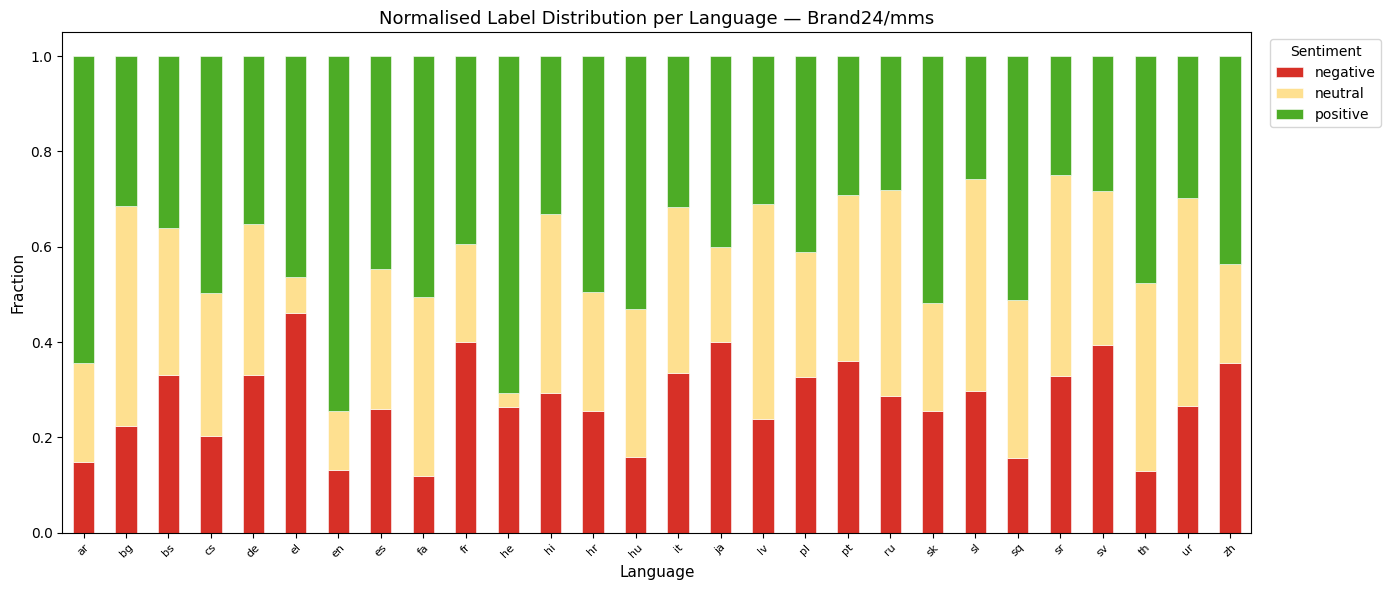

In [10]:
if lang_col and label_col:
    fig, ax = plt.subplots(figsize=(14, 6))
    label_dist_norm.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['#d73027', '#fee090', '#4dac26'],
        edgecolor='white',
        linewidth=0.4,
    )
    ax.set_title('Normalised Label Distribution per Language — Brand24/mms', fontsize=13)
    ax.set_xlabel('Language', fontsize=11)
    ax.set_ylabel('Fraction', fontsize=11)
    ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    fig.tight_layout()
    plt.show()

## 4. Check for parallel-sample ID column

In [11]:
ID_CANDIDATES = ['id', 'sample_id', 'parallel_id', 'doc_id', 'idx']
id_col = next((c for c in ID_CANDIDATES if c in df_all.columns), None)

if id_col:
    print(f'Parallel ID column found: "{id_col}"')
    unique_ids = df_all[id_col].nunique()
    print(f'  Unique IDs       : {unique_ids}')
    print(f'  Total rows       : {len(df_all)}')
    if lang_col:
        counts_per_id = df_all.groupby(id_col)[lang_col].nunique()
        fully_parallel = (counts_per_id == df_all[lang_col].nunique()).sum()
        print(f'  Fully parallel IDs (all languages): {fully_parallel}')
else:
    print('No parallel ID column detected among candidates:', ID_CANDIDATES)
    print('All available columns:', list(df_all.columns))
    print()
    print('ACTION: Inspect the columns above and update build_parallel_samples()')
    print('        in src/data/loader.py once the correct column is identified.')

No parallel ID column detected among candidates: ['id', 'sample_id', 'parallel_id', 'doc_id', 'idx']
All available columns: ['label', 'text', 'cleanlab_self_confidence', 'language', 'original_dataset', 'split', 'label_name']

ACTION: Inspect the columns above and update build_parallel_samples()
        in src/data/loader.py once the correct column is identified.


## 5. Save label_distribution.csv

In [12]:
if lang_col and label_col:
    out_path = SCORES_DIR / 'label_distribution.csv'
    label_dist.to_csv(out_path)
    print(f'Saved → {out_path}')
else:
    print('Skipped: language or label column not found.')

Saved → /Users/laetitiasimon/clcs-eval/results/scores/label_distribution.csv
